# ICU Infection Prevention Adherence: Inferential Statistics Part 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_rater = pd.read_csv('data/icu_adherence_by_rater.csv')
df_items = pd.read_csv('data/icu_adherence_by_item.csv').iloc[:, 1:]

df_rater_avg = df_rater.groupby(['icu_id', 'icu_type'])[['clabsi_score', 'cauti_score', 'vap_score']].mean()
df_rater_avg.reset_index(inplace=True)
df_rater_avg.head(10)

,icu_id,icu_type,clabsi_score,cauti_score,vap_score
0,1,General,77.845,74.760,64.780
1,2,General,61.175,78.335,80.435
2,3,General,73.135,77.740,76.955
3,4,General,79.310,90.715,77.395
4,5,General,70.785,73.215,87.395
5,6,General,69.510,65.240,68.265
6,7,General,69.510,70.240,68.045
7,8,General,70.100,86.670,67.610
8,9,General,64.415,70.950,67.825
9,10,Surgical,88.925,87.020,66.525


## Paired Samples Analysis: Comparing Rater Reports

In this section, we'll analyze the data to see if there is agreement and any significant difference between the adherence scores as reported by Head Nurses and Attending Physicians.

### Descriptive Statistics by Rater

In [3]:
rater_stats = df_rater.groupby('rater')[['clabsi_score', 'cauti_score', 'vap_score']].describe()
rater_stats

clabsi_score                                                       \
                 count     mean        std    min      25%     50%      75%   
rater                                                                         
Attending         20.0  78.9215  10.557746  60.00  69.7525  80.000  89.2675   
HeadNurse         20.0  77.7065  14.182048  38.04  69.0725  82.645  88.8750   

                 cauti_score           ...                 vap_score           \
             max       count     mean  ...      75%    max     count     mean   
rater                                  ...                                      
Attending  91.96        20.0  82.1905  ...  88.7525  94.52      20.0  75.3480   
HeadNurse  91.76        20.0  81.8340  ...  87.6175  93.33      20.0  71.6085   

                                                            
                std    min      25%    50%      75%    max  
rater                                                       
Attending  8.357067  57.39  68.7000  75.65  82.4975  87.83  
HeadNurse  8.032650  48.70  68.1525  72.17  75.7600  86.96  

[2 rows x 24 columns]

### Correlation Between Rater Reports

In [4]:
# Pivot the data to get HeadNurse and Attending scores side-by-side for each ICU
df_paired = df_rater.pivot(index='icu_id', columns='rater', values=['clabsi_score', 'cauti_score', 'vap_score'])
df_paired

clabsi_score           cauti_score           vap_score          
rater     Attending HeadNurse   Attending HeadNurse Attending HeadNurse
icu_id                                                                 
1             67.45     88.24       71.90     77.62     57.39     72.17
2             60.00     62.35       73.81     82.86     84.35     76.52
3             71.37     74.90       75.24     80.24     81.74     72.17
4             78.82     79.80       92.38     89.05     86.09     68.70
5             70.98     70.59       73.10     73.33     87.83     86.96
6             75.88     63.14       70.00     60.48     87.83     48.70
7             69.80     69.22       70.24     70.24     68.70     67.39
8             69.61     70.59       86.67     86.67     67.39     67.83
9             64.12     64.71       70.95     70.95     67.39     68.26
10            89.22     88.63       86.90     87.14     68.70     64.35
11            89.41     90.00       88.10     84.76     70.43     74.78
12            90.59     91.37       85.48     83.10     75.65     73.91
13            91.37     91.57       82.38     83.81     69.57     64.35
14            89.61     89.61       94.52     93.33     75.65     75.65
15            91.96     91.76       94.29     92.86     76.52     76.09
16            86.27     85.49       82.86     82.86     73.04     72.17
17            81.18     38.04       87.62     79.05     75.65     70.43
18            88.63     88.63       90.71     90.71     83.48     79.13
19            84.71     86.86       90.95     90.95     82.17     84.35
20            67.45     68.63       75.71     76.67     67.39     68.26

In [5]:
from scipy.stats import pearsonr

# Calculate correlations for each bundle score
clabsi_corr, clabsi_p = pearsonr(df_paired['clabsi_score']['Attending'], df_paired['clabsi_score']['HeadNurse'])
cauti_corr, cauti_p = pearsonr(df_paired['cauti_score']['Attending'], df_paired['cauti_score']['HeadNurse'])
vap_corr, vap_p = pearsonr(df_paired['vap_score']['Attending'], df_paired['vap_score']['HeadNurse'])

print('Pearson Correlation between Raters')
print(f'CLABSI: r = {clabsi_corr:.3f}, p-value = {clabsi_p:.3f}')
print(f'CAUTI: r = {cauti_corr:.3f}, p-value = {cauti_p:.3f}')
print(f'VAP: r = {vap_corr:.3f}, p-value = {vap_p:.3f}')

Pearson Correlation between Raters
CLABSI: r = 0.612, p-value = 0.004
CAUTI: r = 0.881, p-value = 0.000
VAP: r = 0.197, p-value = 0.404


**Interpretation of Rater Correlations:**:
There is a significant positive correlation between the reports of Head Nurses and Attending Physicians for CLABSI and CAUTI categories. The agreement is particularly strong for CAUTI scores (r= 0.881). This indicates that for these two categories, both types of raters tended to score ICUs similarly. However, there is no significant correlation for VAP prevention scores, suggesting a lack of agreement in how the two groups rated adherence to ventilator protocols.

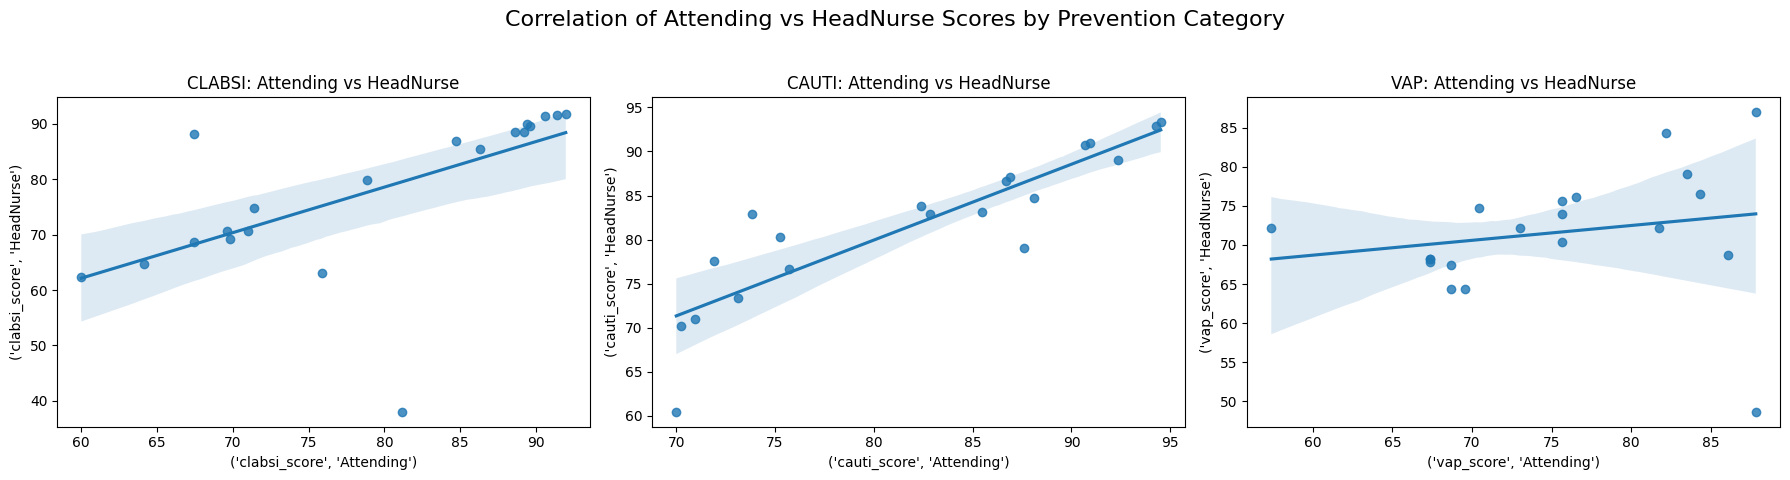

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Correlation of Attending vs HeadNurse Scores by Prevention Category', fontsize=16)

# CLABSI
sns.regplot(
    ax=axes[0],
    x=df_paired[('clabsi_score', 'Attending')],
    y=df_paired[('clabsi_score', 'HeadNurse')]
)
axes[0].set_title('CLABSI: Attending vs HeadNurse')

# CAUTI
sns.regplot(
    ax=axes[1],
    x=df_paired[('cauti_score', 'Attending')],
    y=df_paired[('cauti_score', 'HeadNurse')]
)
axes[1].set_title('CAUTI: Attending vs HeadNurse')

# VAP
sns.regplot(
    ax=axes[2],
    x=df_paired[('vap_score', 'Attending')],
    y=df_paired[('vap_score', 'HeadNurse')]
)
axes[2].set_title('VAP: Attending vs HeadNurse')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Paired Samples T-Test

In [7]:
from scipy.stats import ttest_rel

# Paired t-test for CLABSI
clabsi_t, clabsi_p_ttest = ttest_rel(df_paired['clabsi_score']['Attending'], df_paired['clabsi_score']['HeadNurse'])

# Paired t-test for CAUTI
cauti_t, cauti_p_ttest = ttest_rel(df_paired['cauti_score']['Attending'], df_paired['cauti_score']['HeadNurse'])

# Paired t-test for VAP
vap_t, vap_p_ttest = ttest_rel(df_paired['vap_score']['Attending'], df_paired['vap_score']['HeadNurse'])

print('Paired Samples T-Test Results')
print(f'CLABSI: T-statistic = {clabsi_t:.3f}, p-value = {clabsi_p_ttest:.3f}')
print(f'CAUTI: T-statistic = {cauti_t:.3f}, p-value = {cauti_p_ttest:.3f}')
print(f'VAP: T-statistic = {vap_t:.3f}, p-value = {vap_p_ttest:.3f}')

Paired Samples T-Test Results
CLABSI: T-statistic = 0.478, p-value = 0.638
CAUTI: T-statistic = 0.379, p-value = 0.709
VAP: T-statistic = 1.610, p-value = 0.124


**Interpretation of Paired Samples T-Test**:\
The results of the t-tests show that for all three categories, the p-values are well above 0.05. This means that although the mean scores reported by Attending Physicians were slightly higher, the difference between the two raters' scores is not statistically significant. We cannot conclude that one group systematically rated adherence higher or lower than the other.